In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


music_data = pd.read_csv('music.csv')
X = music_data.drop(columns=['genre'])
y = music_data['genre']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)
score

1.0

In [66]:
import numpy as np
from scipy import sparse

eye = np.eye(4)
# print('Numpy array=\n{}'.format(eye))

sparse_matrix = sparse.csr_matrix(eye)
print('Sparse matrix \n{}'.format(sparse_matrix))

Sparse matrix 
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


In [67]:
data = np.ones(4)
row_indices = np.arange(4)
col_indices = np.arange(4)
eye_coo = sparse.coo_matrix((data, (row_indices, col_indices)))
print('Coo representation: \n{}'.format(eye_coo))


Coo representation: 
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


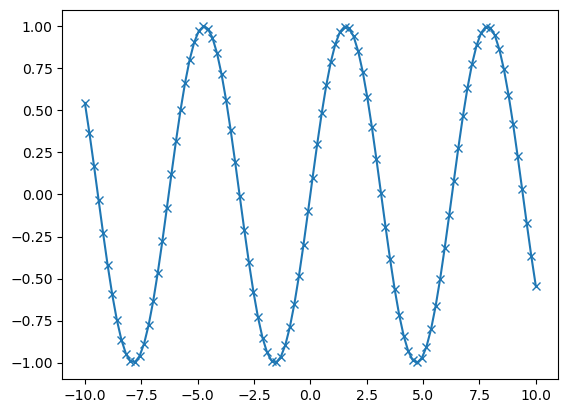

In [68]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = np.sin(x)

plt.plot(x, y, marker="x")



In [69]:
import pandas as pd

data = {'Name': ['John', 'Anna', 'Peter', 'Linda'],
       'Location': ['New York', 'Paris', 'Berlin', 'London'],
       'Age': [24, 13, 53, 33]}

df = pd.DataFrame(data)
df[df.Age>30]

,Name,Location,Age
2,Peter,Berlin,53
3,Linda,London,33


In [70]:
from sklearn.datasets import load_iris
import pandas as pd
import mglearn
import numpy as np
iris_dataset = load_iris()

# print('Keys of iris_dataset: \n{}'.format(iris_dataset.keys()))

# print(iris_dataset['data'][:5])

iris_dataset['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [71]:
pip install mglearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

In [73]:
print('X_train shape: {}'.format(X_train.shape))
print('y_train shape: {}'.format(y_train.shape))

X_train shape: (112, 4)
y_train shape: (112,)


In [74]:
print('X_test shape : {}'.format(X_test.shape))
print('y_test shape : {}'.format(y_test.shape))

X_test shape : (38, 4)
y_test shape : (38,)


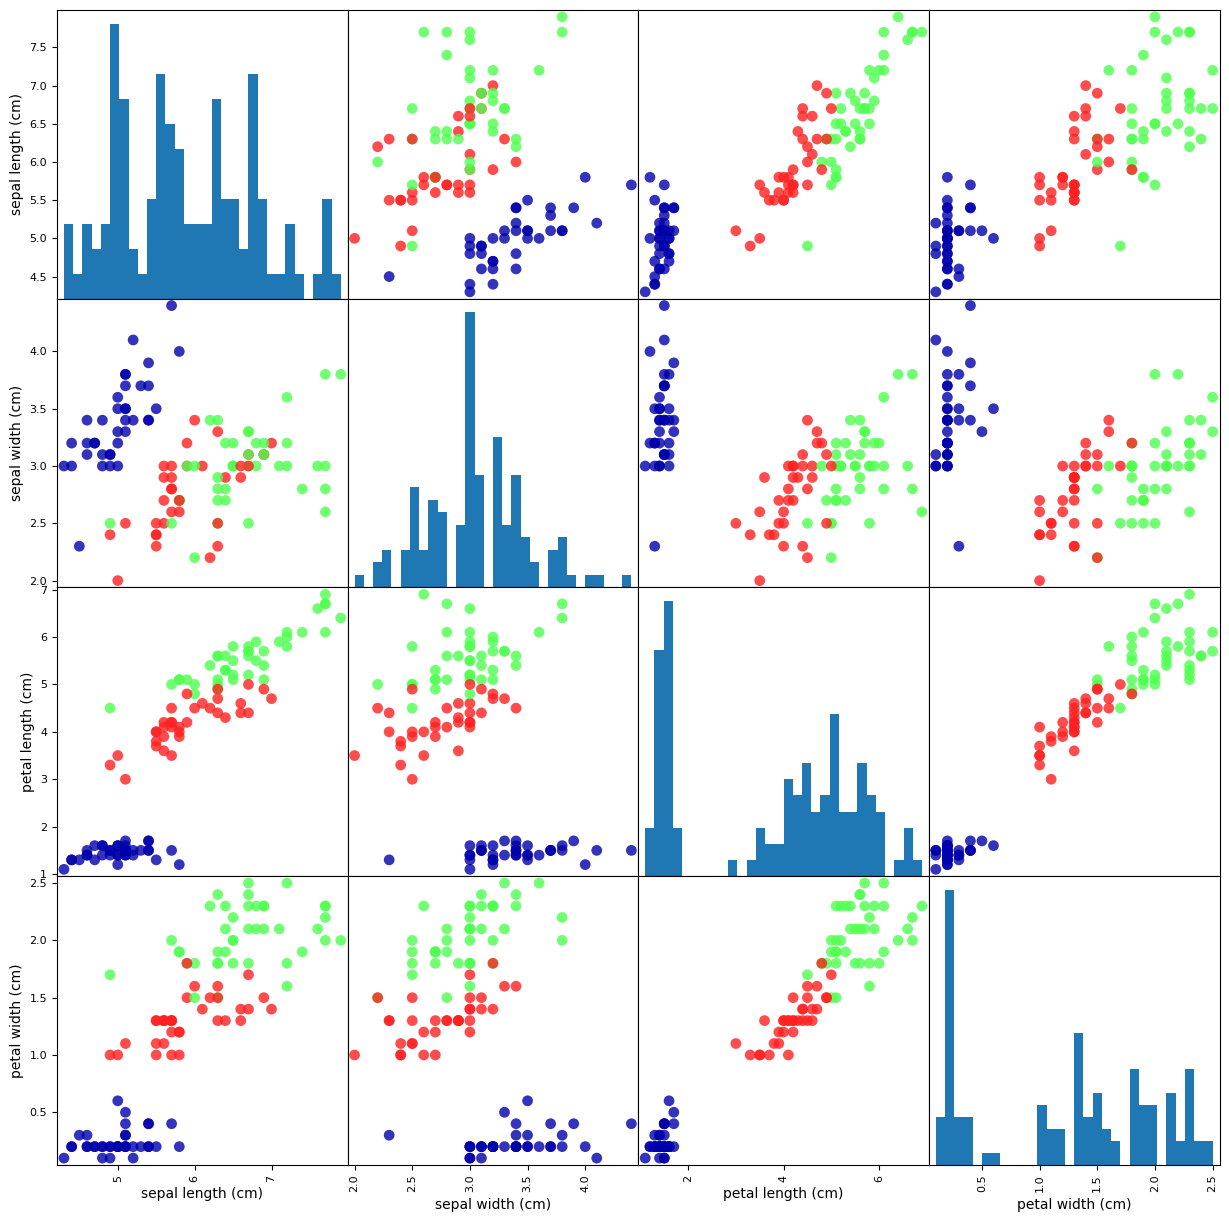

In [93]:
# create dataframe from data in X_train
# label the column using the strings in iris_dataset.features_names
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)

#create a scatter matrix from the dataframe, color by y_train
grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15), marker='o',
                       hist_kwds={'bins': 30}, s=60, alpha=0.8, cmap=mglearn.cm3)

In [76]:
iris_dataframe

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.9,3.0,4.2,1.5
1,5.8,2.6,4.0,1.2
2,6.8,3.0,5.5,2.1
3,4.7,3.2,1.3,0.2
4,6.9,3.1,5.1,2.3
...,...,...,...,...
107,4.9,3.1,1.5,0.1
108,6.3,2.9,5.6,1.8
109,5.8,2.7,4.1,1.0
110,7.7,3.8,6.7,2.2


In [77]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)
KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=1, n_neighbors=1, 
                    p=2,weights='uniform')
X_new = np.array([[5, 2.9, 1, 0.2]])

print('X_new.shape: {}'.format(X_new.shape))

X_new.shape: (1, 4)


In [94]:
prediction = knn.predict(X_new)
# print('Prediction: {}'.format(prediction))
print('Predictied target name: {}'.format(iris_dataset['target_names'][prediction]))

Predictied target name: ['setosa']


In [95]:
y_pred = knn.predict(X_test)
print('Test set predictions:\n {}'.format(y_pred))


Test set predictions:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [80]:
print('Test set score: {:.2f}'.format(np.mean(y_pred==y_test)))

Test set score: 0.97


In [81]:
print('Test set score: {:.2f}'.format(knn.score(X_test, y_test)))

Test set score: 0.97
